In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # macOS
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스나 colab 등

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지


In [3]:
rename_dict = {
    "일시": "날짜",
    "평균기온(°C)": "평균 기온",
    "최저기온(°C)": "최저 기온",
    "최고기온(°C)": "최고 기온",
    "일강수량(mm)": "강수량"
}

recent = pd.read_csv("./weather_csv/weather_data1.csv", encoding="cp949").rename(columns=rename_dict)
past = pd.read_csv("./weather_csv/weather_past_data1.csv", encoding="cp949").rename(columns=rename_dict)

df = pd.concat([recent, past], ignore_index=True)
df = df[["날짜", "평균 기온", "최저 기온", "최고 기온", "강수량"]]
df["날짜"] = pd.to_datetime(df["날짜"])
df["평균 기온"] = pd.to_numeric(df["평균 기온"], errors="coerce")
df["최저 기온"] = pd.to_numeric(df["최저 기온"], errors="coerce")
df["최고 기온"] = pd.to_numeric(df["최고 기온"], errors="coerce")
df["강수량"] = pd.to_numeric(df["강수량"], errors="coerce").fillna(0)

In [4]:
df.head()

,날짜,평균 기온,최저 기온,최고 기온,강수량
0,2020-01-01,-2.2,-6.5,0.3,0.1
1,2020-01-02,1.0,-0.7,3.8,0.0
2,2020-01-03,-0.1,-3.4,4.6,0.0
3,2020-01-04,1.2,-2.8,6.1,0.0
4,2020-01-05,1.3,-3.2,6.6,0.0


In [7]:
df.tail()

,날짜,평균 기온,최저 기온,최고 기온,강수량
3648,1999-12-27,0.7,-4.5,5.9,0.0
3649,1999-12-28,3.4,-0.4,6.6,1.3
3650,1999-12-29,0.2,-4.3,5.2,0.0
3651,1999-12-30,1.7,-3.5,7.7,0.0
3652,1999-12-31,3.5,0.0,7.3,0.0


In [4]:
solar_terms = {
    "입춘": "02-04", "우수": "02-19", "경칩": "03-05", "춘분": "03-20", "청명": "04-04", "곡우": "04-20",
    "입하": "05-05", "소만": "05-21", "망종": "06-05", "하지": "06-21", "소서": "07-07", "대서": "07-22",
    "입추": "08-07", "처서": "08-23", "백로": "09-07", "추분": "09-23", "한로": "10-08", "상강": "10-23",
    "입동": "11-07", "소설": "11-22", "대설": "12-07", "동지": "12-22", "소한": "01-05", "대한": "01-20"
}

In [6]:
# 절기 날짜 +-3일 계산

def extract_term_weather(df, term_dict, window=3):
    results = []
    for term, date_str in term_dict.items():
        for year in df["날짜"].dt.year.unique():
            try:
                term_date = pd.to_datetime(f"{year}-{date_str}")
            except:
                continue
            mask = (df["날짜"] >= term_date - pd.Timedelta(days=window)) & \
                   (df["날짜"] <= term_date + pd.Timedelta(days=window))
            subset = df[mask]
            if len(subset) > 0:
                results.append({
                    "절기": term,
                    "연도": year,
                    "평균기온": subset["평균 기온"].mean(),
                    "최저기온": subset["최저 기온"].mean(),
                    "최고기온": subset["최고 기온"].mean(),
                    "강수량": subset["강수량"].mean()
                })
    return pd.DataFrame(results)

In [7]:
# 절기 데이터
term_df = extract_term_weather(df, solar_terms)
term_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   절기      240 non-null    object 
 1   연도      240 non-null    int32  
 2   평균기온    240 non-null    float64
 3   최저기온    240 non-null    float64
 4   최고기온    240 non-null    float64
 5   강수량     240 non-null    float64
dtypes: float64(4), int32(1), object(1)
memory usage: 10.4+ KB


In [8]:
past_df = term_df[term_df["연도"].between(1995, 1999)].copy()
recent_df = term_df[term_df["연도"].between(2020, 2024)].copy()

In [9]:
def calc_std(df, label):
    std = df.groupby("절기")[["평균기온", "최저기온", "최고기온"]].std().reset_index()
    std["구간"] = label
    return std

past_std = calc_std(past_df, "1995~1999")
recent_std = calc_std(recent_df, "2020~2024")

std_compare = pd.concat([past_std, recent_std], ignore_index=True)

In [10]:
merged_std = past_std.merge(recent_std, on="절기", suffixes=("_과거", "_최근"))

In [14]:
merged_std

,절기,평균기온_과거,최저기온_과거,최고기온_과거,구간_과거,평균기온_최근,최저기온_최근,최고기온_최근,구간_최근
0,경칩,1.791380,1.412647,2.363973,1995~1999,1.669034,1.485556,2.227092,2020~2024
1,곡우,3.640719,3.428506,3.947712,1995~1999,2.731636,2.049978,3.710253,2020~2024
2,대서,1.772753,1.611901,1.923369,1995~1999,2.416432,1.895338,2.858953,2020~2024
3,대설,2.181944,2.041873,2.045139,1995~1999,2.941876,2.665337,3.102099,2020~2024
4,대한,2.624403,2.605363,2.309510,1995~1999,1.818067,2.064817,1.777306,2020~2024
5,동지,4.329766,4.171624,4.683617,1995~1999,3.429964,3.052373,3.503709,2020~2024
6,망종,2.398350,1.885785,3.025858,1995~1999,0.614252,0.558643,1.095939,2020~2024
7,백로,1.778328,1.650862,2.398086,1995~1999,2.506665,2.515329,2.689120,2020~2024
8,상강,0.483757,0.595613,0.813759,1995~1999,1.390507,1.772885,0.844695,2020~2024
9,소만,2.261465,1.943792,2.358753,1995~1999,1.668661,1.536614,2.010498,2020~2024


In [11]:
std_compare

,절기,평균기온,최저기온,최고기온,구간
0,경칩,1.791380,1.412647,2.363973,1995~1999
1,곡우,3.640719,3.428506,3.947712,1995~1999
2,대서,1.772753,1.611901,1.923369,1995~1999
3,대설,2.181944,2.041873,2.045139,1995~1999
4,대한,2.624403,2.605363,2.309510,1995~1999
5,동지,4.329766,4.171624,4.683617,1995~1999
6,망종,2.398350,1.885785,3.025858,1995~1999
7,백로,1.778328,1.650862,2.398086,1995~1999
8,상강,0.483757,0.595613,0.813759,1995~1999
9,소만,2.261465,1.943792,2.358753,1995~1999


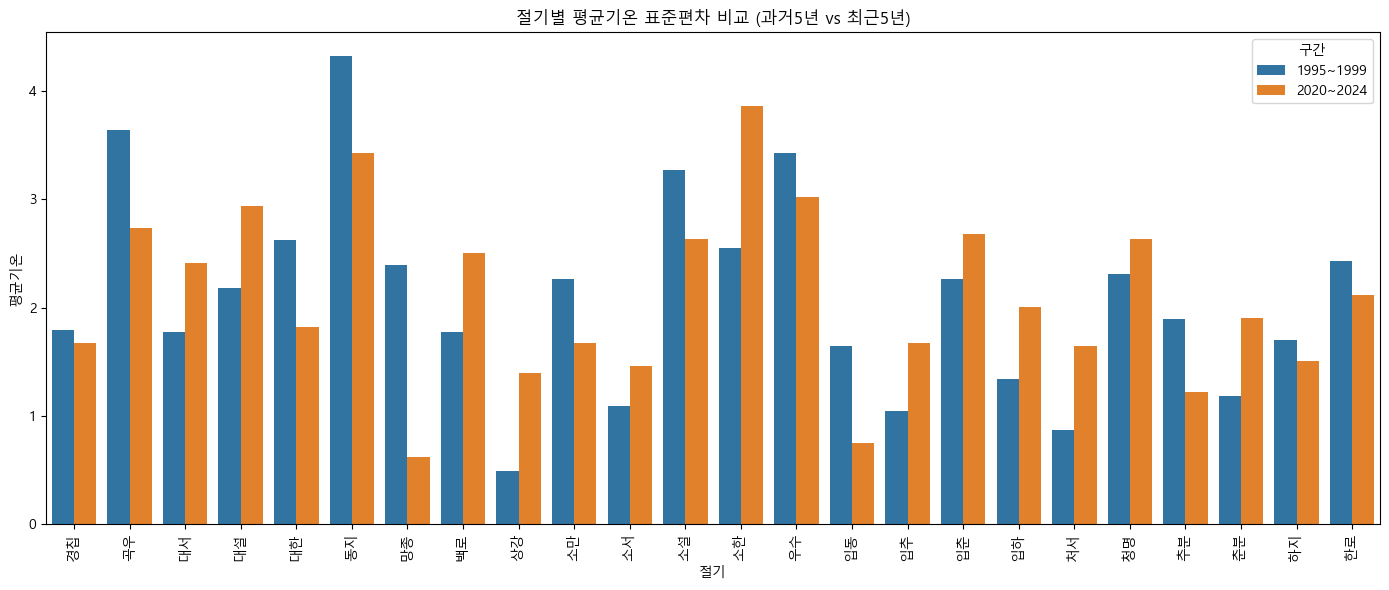

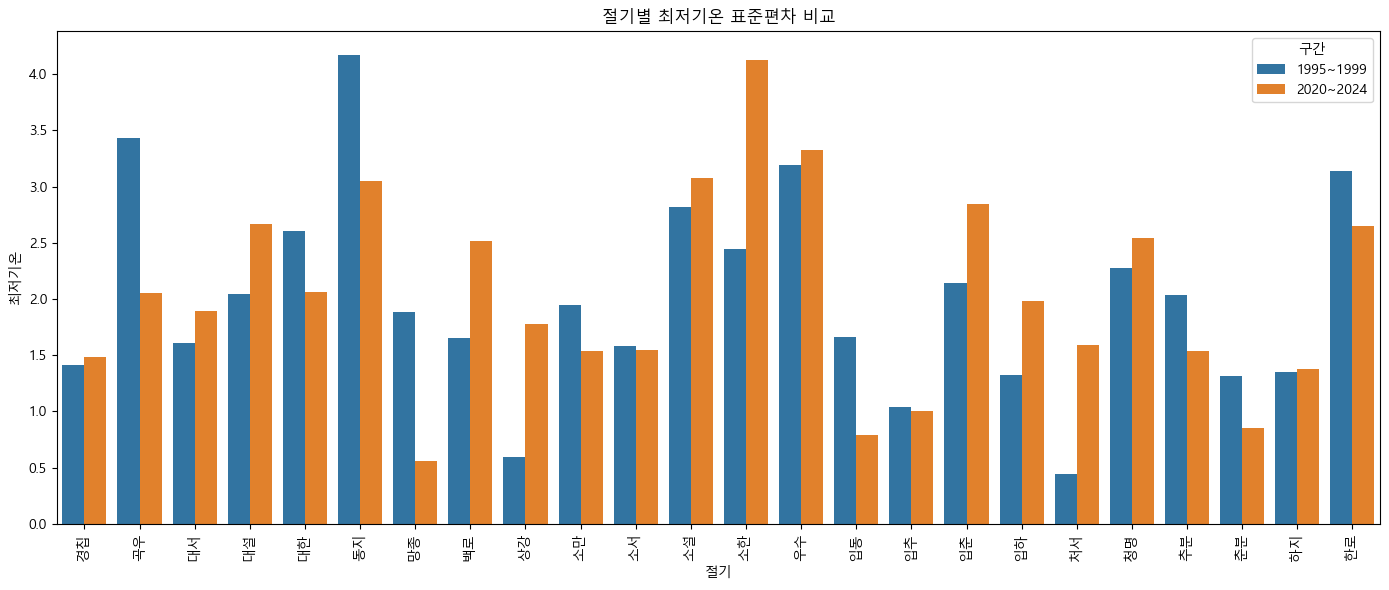

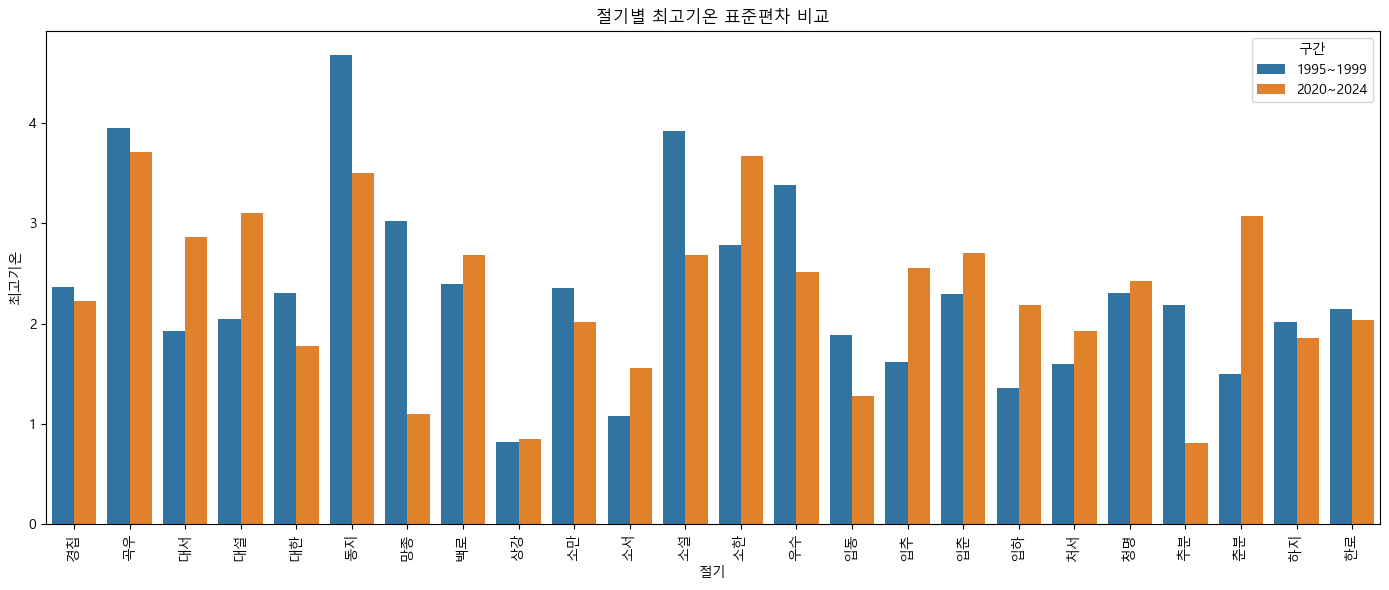

In [11]:
plt.figure(figsize=(14, 6))
sns.barplot(data=std_compare, x="절기", y="평균기온", hue="구간")
plt.title("절기별 평균기온 표준편차 비교 (과거5년 vs 최근5년)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=std_compare, x="절기", y="최저기온", hue="구간")
plt.title("절기별 최저기온 표준편차 비교")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=std_compare, x="절기", y="최고기온", hue="구간")
plt.title("절기별 최고기온 표준편차 비교")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:

# 절기별로 어떤 시기의 표준편차가 더 큰지 비교 (merged_std 기준)
comparison_result = pd.DataFrame()
comparison_result["절기"] = merged_std["절기"]

for col in ["평균기온", "최저기온", "최고기온"]:
    comparison_result[col] = (merged_std[f"{col}_최근"] > merged_std[f"{col}_과거"]).astype(int)

comparison_result["합계"] = comparison_result[["평균기온", "최저기온", "최고기온"]].sum(axis=1)
comparison_result.head()


,절기,평균기온,최저기온,최고기온,합계
0,경칩,0,1,0,1
1,곡우,0,0,0,0
2,대서,1,1,1,3
3,대설,1,1,1,3
4,대한,0,0,0,0


In [13]:

# 각 지표별로 최근이 더 큰 절기의 개수 세기
metric_total = comparison_result[["평균기온", "최저기온", "최고기온"]].sum()
metric_total


평균기온    12
최저기온    13
최고기온    12
dtype: int64

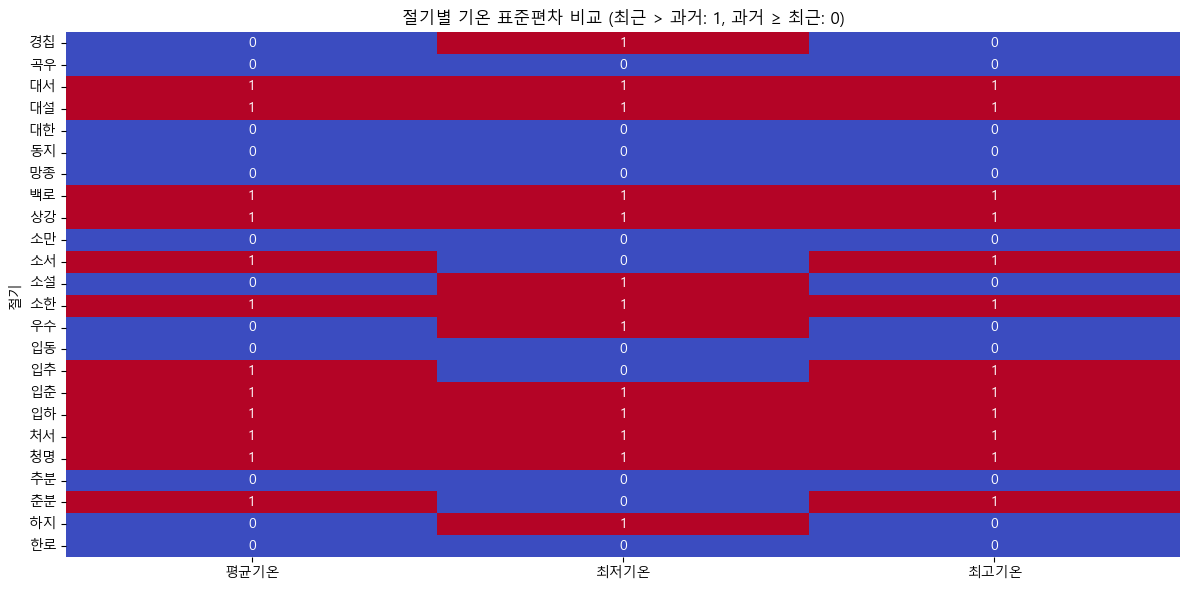

In [14]:

# 절기별 비교 결과 시각화 (히트맵)
plt.figure(figsize=(12, 6))
sns.heatmap(comparison_result.set_index("절기").drop(columns="합계"), annot=True, cmap="coolwarm", cbar=False, fmt="d")
plt.title("절기별 기온 표준편차 비교 (최근 > 과거: 1, 과거 ≥ 최근: 0)")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


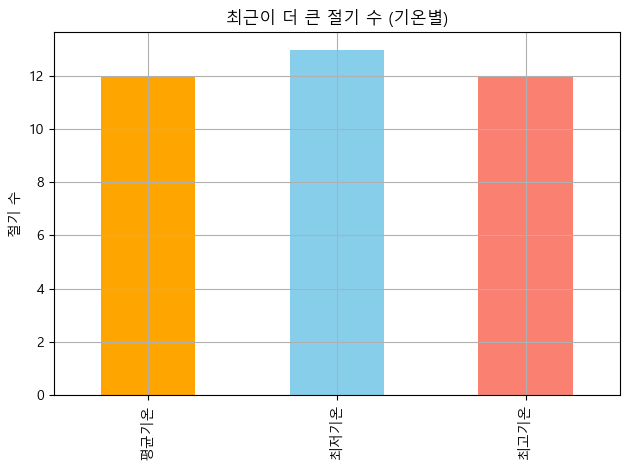

In [15]:

# 지표별로 최근이 더 큰 절기 개수 시각화
metric_total.plot(kind="bar", color=["orange", "skyblue", "salmon"])
plt.title("최근이 더 큰 절기 수 (기온별)")
plt.ylabel("절기 수")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
for col in ["평균기온", "최저기온", "최고기온"]:
    merged_std[f"{col}_증가량"] = merged_std[f"{col}_최근"] - merged_std[f"{col}_과거"]

In [17]:
increase_cols = [f"{col}_증가량" for col in ["평균기온", "최저기온", "최고기온"]]
increase_df = merged_std[increase_cols]
corr_matrix = increase_df.corr()

In [18]:
plot_df = pd.DataFrame()
for col in ["평균기온", "최저기온", "최고기온"]:
    for period in ["과거", "최근"]:
        temp_df = pd.DataFrame({
            "항목": col,
            "표준편차": merged_std[f"{col}_{period}"],
            "시기": period
        })
        plot_df = pd.concat([plot_df, temp_df], ignore_index=True)

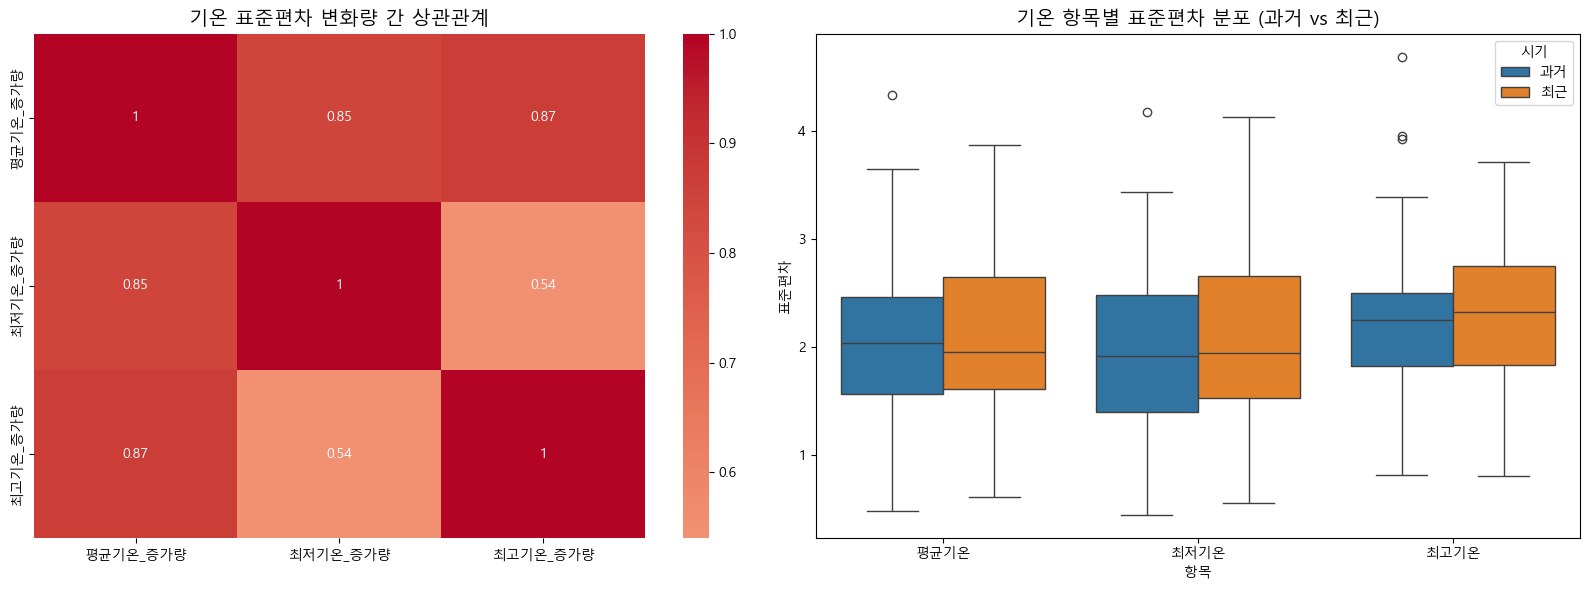

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 상관관계 히트맵 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("기온 표준편차 변화량 간 상관관계", fontsize=14)

# (2) 박스플롯: 기온 항목별 표준편차 분포
sns.boxplot(data=plot_df, x="항목", y="표준편차", hue="시기", ax=axes[1])
axes[1].set_title("기온 항목별 표준편차 분포 (과거 vs 최근)", fontsize=14)
axes[1].legend(title="시기")

plt.tight_layout()
plt.show()
